# 09 - Risk Overlay and Drawdown Control

## Purpose of this notebook

In this notebook, I test practical risk overlays designed to reduce drawdown and improve the usability of the tactical ETF portfolio for real-money deployment.

The earlier strategy notebooks identified strong finalists, but the remaining weakness is that drawdowns can still be uncomfortable. This notebook asks whether I can improve drawdown control without destroying return and Sharpe.

## Main research question

Can I improve the finalist strategies by adding:
- portfolio-level volatility targeting
- simple weight caps
- stronger defensive fallback sleeves

while keeping the original signal logic unchanged?

## Strategy finalists used in this notebook

The main finalists tested here are:
- Shared 180d
- Shared 252d
- Best Static ETF-Level

## Why this notebook matters

This is a practical portfolio-construction upgrade. Instead of changing the signal logic again, I now test whether a risk overlay can make the strategies smoother and more usable in practice.

## 2. Import libraries

In this section, I import the libraries needed to:
- load prior strategy outputs
- build overlay strategies
- compute metrics
- save upgraded strategies for the app

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Load prior strategy outputs

In this section, I load the finalists and their weight histories.

## What this section is doing

I load:
- final comparison return series
- shared strategy weight histories
- ETF-level weight history
- monthly ETF returns

These are the inputs needed to apply the overlays cleanly.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

final_comparison_returns = pd.read_csv(PROCESSED_DIR / "final_comparison_returns.csv", index_col=0, parse_dates=True)
monthly_returns = pd.read_csv(PROCESSED_DIR / "monthly_returns.csv", index_col=0, parse_dates=True)

# IMPORTANT:
# These are target weights, so I shift them by 1 month to create held weights.
shared_180_weights = pd.read_csv(PROCESSED_DIR / "shared_180d_target_weights.csv", index_col=0, parse_dates=True).shift(1)
shared_252_weights = pd.read_csv(PROCESSED_DIR / "shared_252d_target_weights.csv", index_col=0, parse_dates=True).shift(1)

# best_etf_level_weights.csv was already saved as the held/shifted weights from Notebook 06
best_etf_weights = pd.read_csv(PROCESSED_DIR / "best_etf_level_weights.csv", index_col=0, parse_dates=True)

print("Final comparison returns:", final_comparison_returns.shape)
print("Monthly returns:", monthly_returns.shape)
print("Shared 180 held weights:", shared_180_weights.shape)
print("Shared 252 held weights:", shared_252_weights.shape)
print("Best ETF held weights:", best_etf_weights.shape)

Final comparison returns: (62, 10)
Monthly returns: (253, 8)
Shared 180 weights: (242, 8)
Shared 252 weights: (242, 8)
Best ETF weights: (242, 8)


## 4. Align everything to a common monthly index

In this section, I align the return and weight tables to the same monthly dates and shared ETF columns.

## Why this matters

The overlays must be applied consistently across comparable periods.

In [3]:
shared_assets = shared_180_weights.columns.intersection(shared_252_weights.columns).intersection(best_etf_weights.columns).intersection(monthly_returns.columns)
common_index = monthly_returns.index.intersection(shared_180_weights.index).intersection(shared_252_weights.index).intersection(best_etf_weights.index)

monthly_returns = monthly_returns.loc[common_index, shared_assets]
shared_180_weights = shared_180_weights.loc[common_index, shared_assets]
shared_252_weights = shared_252_weights.loc[common_index, shared_assets]
best_etf_weights = best_etf_weights.loc[common_index, shared_assets]

print("Common monthly observations:", len(common_index))
print("Assets:", shared_assets.tolist())

Common monthly observations: 242
Assets: ['EEM', 'EFA', 'GLD', 'IEF', 'IWM', 'QQQ', 'SPY', 'TLT']


## 5. Helper functions

In this section, I define functions for:
- performance metrics
- portfolio return construction
- realized volatility estimation
- overlay application

In [4]:
def compute_metrics(return_series):
    rs = return_series.dropna()
    if len(rs) == 0:
        return {
            "CAGR": np.nan,
            "Annual Vol": np.nan,
            "Sharpe": np.nan,
            "Max Drawdown": np.nan,
            "Calmar": np.nan,
        }

    cumulative = (1 + rs).cumprod()
    total_months = len(rs)

    cagr = cumulative.iloc[-1] ** (12 / total_months) - 1
    ann_vol = rs.std() * np.sqrt(12)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


def compute_portfolio_returns(weight_df, return_df):
    aligned_weights = weight_df.reindex(return_df.index).fillna(0)
    aligned_returns = return_df.reindex(aligned_weights.index).fillna(0)
    return (aligned_weights * aligned_returns).sum(axis=1)


def rolling_portfolio_vol(return_series, window=12):
    return return_series.rolling(window).std() * np.sqrt(12)


def cap_weights(weight_row, cap=0.60):
    w = weight_row.copy().fillna(0)

    if w.sum() <= 0:
        return w

    w = w.clip(upper=cap)

    # redistribute leftover weight among uncapped positive positions
    leftover = 1.0 - w.sum()
    uncapped = w[(w > 0) & (w < cap)]

    if leftover > 1e-12 and len(uncapped) > 0:
        add_on = uncapped / uncapped.sum() * leftover
        for idx in add_on.index:
            w[idx] += add_on[idx]

    if w.sum() > 0:
        w = w / w.sum()

    return w


def apply_weight_cap(weight_df, cap=0.60):
    return weight_df.apply(lambda row: cap_weights(row, cap=cap), axis=1)


def apply_vol_target_overlay(weight_df, return_df, target_vol=0.10, vol_window=12, defensive_asset="IEF"):
    """
    Scale risky sleeve down when realized vol is above target.
    Any leftover goes to defensive_asset.
    """
    base_returns = compute_portfolio_returns(weight_df, return_df)
    realized_vol = rolling_portfolio_vol(base_returns, window=vol_window)

    adjusted_weights = weight_df.copy().fillna(0)

    for dt in adjusted_weights.index:
        row = adjusted_weights.loc[dt].copy()
        sigma = realized_vol.loc[dt]

        if pd.isna(sigma) or sigma <= 0:
            scale = 1.0
        else:
            scale = min(1.0, target_vol / sigma)

        row = row * scale
        leftover = 1.0 - row.sum()

        if defensive_asset in row.index:
            row[defensive_asset] += max(0.0, leftover)

        adjusted_weights.loc[dt] = row

    return adjusted_weights


def apply_vol_target_with_sleeve(weight_df, return_df, target_vol=0.10, vol_window=12, sleeve_map=None):
    """
    Same as vol target overlay, but leftover goes to a defensive sleeve directly.
    Example sleeve_map = {"IEF": 0.5, "GLD": 0.5}
    """
    if sleeve_map is None:
        sleeve_map = {"IEF": 0.5, "GLD": 0.5}

    base_returns = compute_portfolio_returns(weight_df, return_df)
    realized_vol = rolling_portfolio_vol(base_returns, window=vol_window)

    adjusted_weights = weight_df.copy().fillna(0)

    for dt in adjusted_weights.index:
        row = adjusted_weights.loc[dt].copy()
        sigma = realized_vol.loc[dt]

        if pd.isna(sigma) or sigma <= 0:
            scale = 1.0
        else:
            scale = min(1.0, target_vol / sigma)

        row = row * scale
        leftover = 1.0 - row.sum()

        if leftover > 0:
            for asset, frac in sleeve_map.items():
                if asset in row.index:
                    row[asset] += leftover * frac

        adjusted_weights.loc[dt] = row

    return adjusted_weights

## 6. Define base strategies

In this section, I organize the finalists and their base weight histories.

## Why this matters

These are the starting strategies before any overlay is applied.

In [5]:
base_weight_strategies = {
    "Shared_180d": shared_180_weights,
    "Shared_252d": shared_252_weights,
    "Best_Static_ETF_Level": best_etf_weights,
}

base_return_strategies = {
    name: compute_portfolio_returns(weights, monthly_returns)
    for name, weights in base_weight_strategies.items()
}

pd.DataFrame({k: compute_metrics(v) for k, v in base_return_strategies.items()}).T

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d,0.310135,0.122386,2.534072,-0.097381,3.184750
Shared_252d,0.306859,0.121835,2.518638,-0.097381,3.151106
Best_Static_ETF_Level,0.117092,0.123479,0.948276,-0.227819,0.513971


## 7. Overlay 1: Portfolio-level volatility targeting

In this section, I apply a simple portfolio-level volatility targeting overlay.

## What this section is doing

If realized portfolio volatility rises above a target level, risky exposure is scaled down. Leftover weight is sent to the defensive asset.

## Why this matters

This is one of the cleanest ways to reduce drawdown without changing the underlying signal engine.

In [6]:
vol_target_weights = {}
vol_target_returns = {}

for name, weights in base_weight_strategies.items():
    adjusted = apply_vol_target_overlay(
        weight_df=weights,
        return_df=monthly_returns,
        target_vol=0.10,
        vol_window=12,
        defensive_asset="IEF",
    )
    vol_target_weights[name] = adjusted
    vol_target_returns[name + "_VolTarget"] = compute_portfolio_returns(adjusted, monthly_returns)

pd.DataFrame({k: compute_metrics(v) for k, v in vol_target_returns.items()}).T

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d_VolTarget,0.260016,0.103936,2.501680,-0.097424,2.668906
Shared_252d_VolTarget,0.260536,0.107139,2.431762,-0.097381,2.675420
Best_Static_ETF_Level_VolTarget,0.106730,0.103190,1.034302,-0.211207,0.505334


## 8. Overlay 2: Vol targeting plus weight cap

In this section, I add a simple max-position cap on top of the vol-targeted version.

## Why this matters

This reduces concentration risk and may further improve drawdown control.

In [7]:
cap_overlay_weights = {}
cap_overlay_returns = {}

for name, weights in base_weight_strategies.items():
    vt = apply_vol_target_overlay(
        weight_df=weights,
        return_df=monthly_returns,
        target_vol=0.10,
        vol_window=12,
        defensive_asset="IEF",
    )
    capped = apply_weight_cap(vt, cap=0.60)
    cap_overlay_weights[name] = capped
    cap_overlay_returns[name + "_VolTarget_Cap"] = compute_portfolio_returns(capped, monthly_returns)

pd.DataFrame({k: compute_metrics(v) for k, v in cap_overlay_returns.items()}).T

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d_VolTarget_Cap,0.265202,0.105866,2.505072,-0.100171,2.647480
Shared_252d_VolTarget_Cap,0.263742,0.109323,2.412507,-0.100171,2.632906
Best_Static_ETF_Level_VolTarget_Cap,0.101882,0.106231,0.959059,-0.210894,0.483095


## 9. Overlay 3: Vol targeting plus defensive sleeve

In this section, I replace the single-asset defensive fallback with a small defensive sleeve.

## Sleeve used

For now, I use:
- 50% IEF
- 50% GLD

## Why this matters

A broader defensive sleeve may reduce dependence on one bond ETF during stressed regimes.

In [8]:
sleeve_overlay_weights = {}
sleeve_overlay_returns = {}

for name, weights in base_weight_strategies.items():
    sleeved = apply_vol_target_with_sleeve(
        weight_df=weights,
        return_df=monthly_returns,
        target_vol=0.10,
        vol_window=12,
        sleeve_map={"IEF": 0.5, "GLD": 0.5},
    )
    sleeve_overlay_weights[name] = sleeved
    sleeve_overlay_returns[name + "_VolTarget_Sleeve"] = compute_portfolio_returns(sleeved, monthly_returns)

pd.DataFrame({k: compute_metrics(v) for k, v in sleeve_overlay_returns.items()}).T

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d_VolTarget_Sleeve,0.260016,0.103936,2.501680,-0.097424,2.668906
Shared_252d_VolTarget_Sleeve,0.260536,0.107139,2.431762,-0.097381,2.675420
Best_Static_ETF_Level_VolTarget_Sleeve,0.106730,0.103190,1.034302,-0.211207,0.505334


## 10. Combine all base and overlay strategies

In this section, I combine the original finalists and all overlay variants into one comparison table.

## Why this matters

This will show clearly which overlay actually improves the base strategy and which ones do not.

In [9]:
all_strategies = {}
all_strategies.update(base_return_strategies)
all_strategies.update(vol_target_returns)
all_strategies.update(cap_overlay_returns)
all_strategies.update(sleeve_overlay_returns)

overlay_returns_df = pd.DataFrame(all_strategies).dropna()
overlay_metrics_df = pd.DataFrame({k: compute_metrics(v) for k, v in overlay_returns_df.items()}).T

overlay_metrics_df.sort_values(["Sharpe", "Max Drawdown", "CAGR"], ascending=[False, False, False])

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d,0.310135,0.122386,2.534072,-0.097381,3.184750
Shared_252d,0.306859,0.121835,2.518638,-0.097381,3.151106
Shared_180d_VolTarget_Cap,0.265202,0.105866,2.505072,-0.100171,2.647480
Shared_180d_VolTarget,0.260016,0.103936,2.501680,-0.097424,2.668906
Shared_180d_VolTarget_Sleeve,0.260016,0.103936,2.501680,-0.097424,2.668906
Shared_252d_VolTarget,0.260536,0.107139,2.431762,-0.097381,2.675420
Shared_252d_VolTarget_Sleeve,0.260536,0.107139,2.431762,-0.097381,2.675420
Shared_252d_VolTarget_Cap,0.263742,0.109323,2.412507,-0.100171,2.632906
Best_Static_ETF_Level_VolTarget,0.106730,0.103190,1.034302,-0.211207,0.505334
Best_Static_ETF_Level_VolTarget_Sleeve,0.106730,0.103190,1.034302,-0.211207,0.505334


## 11. Compare each base strategy against its own overlays

In this section, I compare:
- base Shared 180d vs its overlays
- base Shared 252d vs its overlays
- base Best Static ETF-Level vs its overlays

This helps isolate whether the overlay is truly helping each specific strategy.

In [10]:
for base_name in base_weight_strategies.keys():
    family_cols = [c for c in overlay_returns_df.columns if c == base_name or c.startswith(base_name + "_")]
    family_metrics = overlay_metrics_df.loc[family_cols].sort_values(
        ["Sharpe", "Max Drawdown", "CAGR"],
        ascending=[False, False, False]
    )
    print("=" * 100)
    print(base_name)
    display(family_metrics)

Shared_180d


,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d,0.310135,0.122386,2.534072,-0.097381,3.184750
Shared_180d_VolTarget_Cap,0.265202,0.105866,2.505072,-0.100171,2.647480
Shared_180d_VolTarget,0.260016,0.103936,2.501680,-0.097424,2.668906
Shared_180d_VolTarget_Sleeve,0.260016,0.103936,2.501680,-0.097424,2.668906


Shared_252d


,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_252d,0.306859,0.121835,2.518638,-0.097381,3.151106
Shared_252d_VolTarget,0.260536,0.107139,2.431762,-0.097381,2.675420
Shared_252d_VolTarget_Sleeve,0.260536,0.107139,2.431762,-0.097381,2.675420
Shared_252d_VolTarget_Cap,0.263742,0.109323,2.412507,-0.100171,2.632906


Best_Static_ETF_Level


,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Best_Static_ETF_Level_VolTarget,0.106730,0.103190,1.034302,-0.211207,0.505334
Best_Static_ETF_Level_VolTarget_Sleeve,0.106730,0.103190,1.034302,-0.211207,0.505334
Best_Static_ETF_Level_VolTarget_Cap,0.101882,0.106231,0.959059,-0.210894,0.483095
Best_Static_ETF_Level,0.117092,0.123479,0.948276,-0.227819,0.513971


## 12. Plot cumulative performance for the strongest overlay candidates

In this section, I compare the cumulative performance of the strongest base and overlay versions.

## Why this matters

This gives a visual sense of whether drawdown improvements come at too high a return cost.

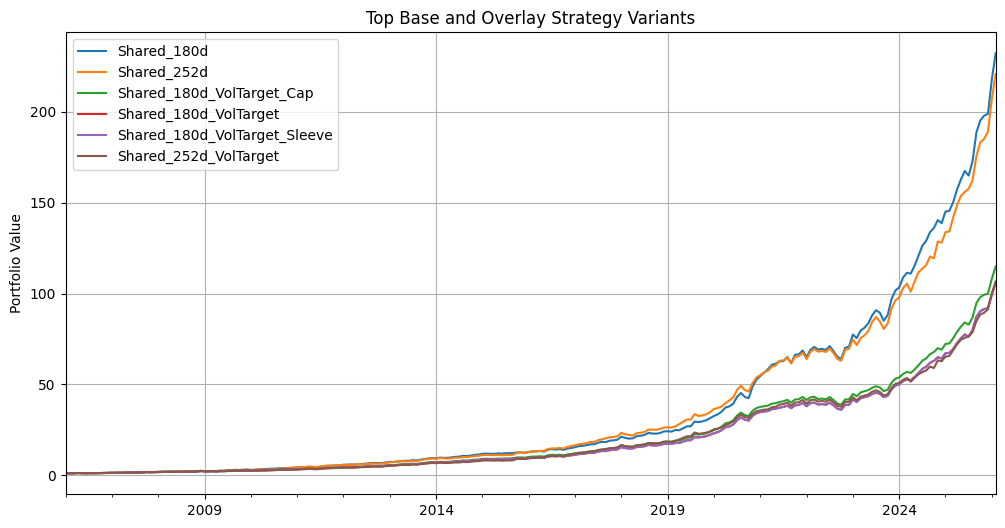

In [11]:
top_plot_cols = overlay_metrics_df.sort_values(
    ["Sharpe", "Max Drawdown", "CAGR"],
    ascending=[False, False, False]
).head(6).index.tolist()

(1 + overlay_returns_df[top_plot_cols]).cumprod().plot(title="Top Base and Overlay Strategy Variants")
plt.ylabel("Portfolio Value")
plt.show()

## 13. Save overlay outputs

In this section, I save:
- combined overlay returns
- overlay metrics
- weight histories for each upgraded strategy

## Why this matters

This makes app integration easy. Each upgraded strategy can be registered later without rebuilding the research.

In [12]:
overlay_returns_df.to_csv(PROCESSED_DIR / "risk_overlay_returns.csv")
overlay_metrics_df.to_csv(PROCESSED_DIR / "risk_overlay_metrics.csv")

# Save representative upgraded strategy weight histories
for name, weights in vol_target_weights.items():
    weights.to_csv(PROCESSED_DIR / f"{name.lower()}_vol_target_weights.csv")

for name, weights in cap_overlay_weights.items():
    weights.to_csv(PROCESSED_DIR / f"{name.lower()}_vol_target_cap_weights.csv")

for name, weights in sleeve_overlay_weights.items():
    weights.to_csv(PROCESSED_DIR / f"{name.lower()}_vol_target_sleeve_weights.csv")

print("Saved overlay returns, metrics, and weight histories.")

Saved overlay returns, metrics, and weight histories.


## 14. Key takeaways from this notebook

At this stage, I have tested several risk overlays on the project finalists.

## What I accomplished

- kept the signal engine fixed
- tested portfolio-level volatility targeting
- tested simple position caps
- tested a broader defensive sleeve
- compared all upgraded strategies against the original finalists
- saved the upgraded strategies in a format that can be added to the dashboard later

## What I learned

This notebook tells me whether drawdown reduction is possible without giving up too much CAGR and Sharpe.

## What comes next

The next notebook will upgrade the weighting engine itself:
- inverse-vol
- minimum variance
- risk parity

That will be the more mathematical portfolio-construction upgrade.